# Lab Experiment: Data Collection
## Web Scraping and APIs

**Course:** Data science  Laboratory
**Class:** B.Tech
**Duration:** 2 hours

---

### Aim
To collect data from a web page and from a REST API, and save it as CSV files.

### Objectives
1. Extract data from an HTML page using **BeautifulSoup**
2. Extract a table using **pandas.read_html**
3. Collect data from a **REST API** and parse the JSON response
4. Save all collected data to CSV files

### Software Required
Python 3, `requests`, `beautifulsoup4`, `lxml`, `pandas`, `matplotlib`

### Theory

There are two ways to collect data from the internet:

| | Web Scraping | REST API |
|---|---|---|
| Data format | HTML (meant for humans) | JSON (meant for programs) |
| Tool | BeautifulSoup | requests + json |
| Effort | High | Low |
| Allowed? | Only if the site permits it | Yes, that is what it is for |

**Rule: if an API exists, use the API.** Scrape only when there is no API.

---
## Step 0: Setup

In [2]:
# Install if needed (uncomment the line below)
# !pip install requests beautifulsoup4 lxml pandas matplotlib

import io
import json
import requests
import pandas as pd
import numpy as np
from bs4 import BeautifulSoup
import matplotlib.pyplot as plt
from pathlib import Path

# Folder to store collected data
DATA = Path("data")
DATA.mkdir(exist_ok=True)

print("Setup complete. Data will be saved in:", DATA.resolve())

Setup complete. Data will be saved in: C:\Users\dines\Downloads\Lab-1\Lab-1\data


---
## Step 1: Rules Before Collecting Data

Before scraping any website, check these four things:

1. **Check `robots.txt`** — visit `https://website.com/robots.txt`. It says which pages
   crawlers may visit.
2. **Check the Terms of Service** — many Indian property sites (99acres, MagicBricks)
   do **not** allow automatic data collection.
3. **Go slow** — wait 1–2 seconds between requests. Do not send requests in a fast loop.
4. **Never collect personal data** — no names, phone numbers or email IDs.

In this lab we use a **practice HTML page created on your own computer**, so no website is
disturbed. The API we use (Open-Meteo) is free and openly allows this.

In [4]:
# Check if a website allows scraping
from urllib.robotparser import RobotFileParser

def can_scrape(url):
    rp = RobotFileParser()
    rp.set_url(url.split("/")[0] + "//" + url.split("/")[2] + "/robots.txt")
    try:
        rp.read()
        return rp.can_fetch("*", url)
    except Exception:
        return "could not check (no internet)"

print("Wikipedia :", can_scrap("https://en.wikipedia.org/wiki/Bangalore"))
print("99acres   :", can_scrape("https://www.99acres.com/property-in-bangalore-ffid"))

NameError: name 'can_scrap' is not defined

In [2]:
def can_scrape(url):
    return True

print(can_scrape("test"))

True


In [5]:
from urllib.robotparser import RobotFileParser

def can_scrape(url):
    rp = RobotFileParser()
    rp.set_url(url.split("/")[0] + "//" + url.split("/")[2] + "/robots.txt")
    
    try:
        rp.read()
        return rp.can_fetch("*", url)
    except Exception:
        return "could not check (no internet)"

In [6]:
print("Wikipedia :", can_scrape("https://en.wikipedia.org/wiki/Bangalore"))
print("99acres    :", can_scrape("https://www.99acres.com/property-in-bangalore-ffid"))

Wikipedia : False
99acres    : False


---
# EXPERIMENT 1
## Collecting Data from an HTML Page

We will collect Bengaluru house listings from a web page.

**How scraping works:**

```
HTML page  →  BeautifulSoup  →  find the tags  →  get the text  →  DataFrame  →  CSV
```

[![Chat-GPT-Image-Aug-13-2026-06-43-45-PM.png](https://i.postimg.cc/NjJc6QCL/Chat-GPT-Image-Aug-13-2026-06-43-45-PM.png)](https://postimg.cc/JskvmCLW)

In [7]:
import requests
from bs4 import BeautifulSoup
import pandas as pd

# 1. Online website
ur1 = "https://quotes.toscrape.com/"

# 2. Read the web page
response = requests.get(url)

# 3. Parse HTML
soup = BeautifulSoup(response.text, "html.parser")

# 4. Find the required tags
quotes = soup.find_all("span", class_="quote")

# 5. Extract the text
data = []

for quote in quotes:
    text = quote.find("span", class_="text").get_text(strip=True)
    author = quote.find("small", class_="author").get_text(strip=True)

    data.append({
        "Quote": text,
        "Author": author
    })

# 6. Create DataFrame
df = pd.DataFrame(data)

print(df)

# 7. Save to CSV
df.to_csv("quotes.csv", index=False)

print("Data saved to quotes.csv")

                                               Quote             Author
0  “The world as we have created it is a process ...    Albert Einstein
1  “It is our choices, Harry, that show what we t...       J.K. Rowling
2  “There are only two ways to live your life. On...    Albert Einstein
3  “The person, be it gentleman or lady, who has ...        Jane Austen
4  “Imperfection is beauty, madness is genius and...     Marilyn Monroe
5  “Try not to become a man of success. Rather be...    Albert Einstein
6  “It is better to be hated for what you are tha...         André Gide
7  “I have not failed. I've just found 10,000 way...   Thomas A. Edison
8  “A woman is like a tea bag; you never know how...  Eleanor Roosevelt
9  “A day without sunshine is like, you know, nig...       Steve Martin
Data saved to quotes.csv


In [7]:
import json
import re
import pandas as pd
 
INPUT_FILE = "data/House.html"
OUTPUT_FILE = "bengaluru_houses.csv"
 
 
# ---------- STEP 1: read the file ----------
html = open(INPUT_FILE, encoding="utf-8").read()
print("File read. Size:", len(html), "characters")
 
 
# ---------- STEP 2: cut out the JSON ----------
marker = "window.__initialData__="
start = html.find(marker) + len(marker)
 

File read. Size: 1774012 characters


##### Find where the marker ends; that's where the embedded data starts

In [11]:
decoder = json.JSONDecoder()

data, end = decoder.raw_decode(html[start:])

print("JSON boundary found successfully")
print("JSON ends at character:", start + end)

JSON boundary found successfully
JSON ends at character: 1758535


In [12]:
properties = data["srp"]["pageData"]["properties"]

print("JSON loaded successfully")
print("Number of listings found:", len(properties))

JSON loaded successfully
Number of listings found: 27


##### depth acts like a brace counter. It starts counting when { appears and stops when all the opened { braces have been closed by matching } braces.

In [15]:
import json
import pandas as pd

# ============================================================
# STEP 1: Read the HTML file
# ============================================================

INPUT_FILE = "data/House.html"
OUTPUT_FILE = "bengaluru_houses.csv"

html = open(INPUT_FILE, encoding="utf-8").read()

print("File read successfully")
print("File size:", len(html), "characters")


# ============================================================
# STEP 2: Find the embedded JSON
# ============================================================

marker = "window.__initialData__="

start = html.find(marker)

if start == -1:
    raise ValueError("Could not find the JSON data in House.html")

start = start + len(marker)

print("JSON starting position:", start)


# ============================================================
# STEP 3: Decode ONLY the JSON object
# ============================================================

decoder = json.JSONDecoder()

data, end = decoder.raw_decode(html[start:])

print("JSON loaded successfully")
print("JSON ending position:", start + end)


# ============================================================
# STEP 4: Get the property listings
# ============================================================

properties = data["srp"]["pageData"]["properties"]

print("Number of listings found:", len(properties))


# ============================================================
# STEP 5: Convert the required values
# ============================================================

def price_in_lakh(rupees):
    """
    Convert rupees to lakh.
    Example:
    21998600 -> 219.99 lakh
    """
    try:
        return round(float(rupees) / 100000, 2)
    except (TypeError, ValueError):
        return None


def to_number(value):
    """
    Convert a value to a number.
    Example:
    "2600" -> 2600.0
    None -> None
    """
    try:
        return float(value)
    except (TypeError, ValueError):
        return None


# ============================================================
# STEP 6: Extract property information
# ============================================================

rows = []

for p in properties:

    rows.append({
        "location": p.get("LOCALITY"),
        "bhk": to_number(p.get("BEDROOM_NUM")),
        "sqft": to_number(p.get("LOCALIZED_AREA_VALUE")),
        "area_unit": p.get("LOCALIZED_AREA_UNIT_LABEL"),
        "price_lakh": price_in_lakh(p.get("MIN_PRICE")),
        "price_text": p.get("PRICE"),
        "price_per_sqft": to_number(p.get("PRICE_SQFT")),
        "property_name": p.get("PROP_NAME")
    })


# ============================================================
# STEP 7: Create DataFrame
# ============================================================

houses = pd.DataFrame(rows)

print("\nDataFrame created successfully")


# ============================================================
# STEP 8: Quick data check
# ============================================================

print("\nAll areas in sqft?",
      (houses["area_unit"] == "sqft").all())

print("\nMissing values:")
print(houses.isna().sum())


# ============================================================
# STEP 9: Save as CSV
# ============================================================

houses.to_csv(OUTPUT_FILE, index=False)

print("\nSaved", len(houses), "rows to", OUTPUT_FILE)


# ============================================================
# STEP 10: Display first 10 properties
# ============================================================

print("\nFirst 10 property listings:")
print(houses.head(10).to_string(index=False))

File read successfully
File size: 1774012 characters
JSON starting position: 1131731
JSON loaded successfully
JSON ending position: 1758535
Number of listings found: 27

DataFrame created successfully

All areas in sqft? True

Missing values:
location          0
bhk               0
sqft              0
area_unit         0
price_lakh        0
price_text        0
price_per_sqft    0
property_name     0
dtype: int64

Saved 27 rows to bengaluru_houses.csv

First 10 property listings:
                        location  bhk   sqft area_unit  price_lakh      price_text  price_per_sqft              property_name
          Bommasandra, Bangalore  5.0 2600.0      sqft      219.99          2.2 Cr          8461.0                SKR Gardens
5th Block Hbr Layout, HBR Layout 12.0 1200.0      sqft      380.00          3.8 Cr         31666.0                           
        Sarjapur Road, Bangalore  4.0 3040.0      sqft      225.00 2.25  - 3.28 Cr          9087.0 CasaLife by Bhavisha Homes
           W

##### Write a Python program that reads the provided Magicbricks HTML webpage, extracts house/property details for Bengaluru, and saves the collected information into a CSV file.

### Result — Experiment 1

**Number of listings collected: 27**

**Columns collected:8**

**File saved:bengaluru_houses.csv**

**Observation:The HTML webpage was successfully processed and Bengaluru property details were extracted into a DataFrame. 27 property listings were collected with 8 attributes, with no missing values. The collected data was successfully saved as a CSV file.**

> ...

---
# EXPERIMENT 2
## Collecting Data from a REST API (Weather)

We will collect Bengaluru weather data from the **Open-Meteo API**.
It is free and needs **no API key**.

**How an API call works:**

```
https://api.open-meteo.com/v1/forecast ? latitude=12.97 & longitude=77.59 & hourly=temperature_2m
|________ address of the API _________|  |____________ what we are asking for ____________|
```

The API replies with **JSON**, which Python reads as a dictionary.

**Important status codes:**

| Code | Meaning |
|------|---------|
| 200 | Success |
| 404 | Not found |
| 429 | Too many requests — slow down |
| 500 | Server problem |

[![44.png](https://i.postimg.cc/05hNftLY/44.png)](https://postimg.cc/K4rFc5cj)

In [17]:
import requests
import pandas as pd

# Step 1: Define the Open-Meteo API
URL = "https://api.open-meteo.com/v1/forecast"

# Step 2: Define Bengaluru coordinates and weather variables
params = {
    "latitude": 12.9716,
    "longitude": 77.5946,
    "current": "temperature_2m,relative_humidity_2m,wind_speed_10m",
    "timezone": "Asia/Kolkata"
}

# Step 3: Send request to the API
try:
    response = requests.get(URL, params=params, timeout=20)

    print("Status code:", response.status_code)

    weather = response.json()

except Exception as e:
    weather = None
    print("No internet:", e)

# Step 4: Display the current weather
if weather:
    print("\nCurrent weather in Bengaluru:")

    for key, value in weather["current"].items():
        print(f"  {key:22s}: {value}")

Status code: 200

Current weather in Bengaluru:
  time                  : 2026-08-31T11:00
  interval              : 900
  temperature_2m        : 26.1
  relative_humidity_2m  : 58
  wind_speed_10m        : 19.4


In [19]:
# --- Step 2b: Collect hourly weather for the next 7 days ---

params2 = {
    "latitude": 12.9716,
    "longitude": 77.5946,
    "hourly": "temperature_2m,relative_humidity_2m,precipitation",
    "timezone": "Asia/Kolkata",
    "forecast_days": 7
}

try:
    response = requests.get(URL, params=params2, timeout=20)

    print("Status code:", response.status_code)

    result = response.json()

    wx = pd.DataFrame(result["hourly"])

    wx["time"] = pd.to_datetime(wx["time"])

    print("Collected", len(wx), "hourly records")

except Exception as e:
    wx = pd.DataFrame()
    print("Error:", e)

wx.head()

Status code: 200
Collected 168 hourly records


,time,temperature_2m,relative_humidity_2m,precipitation
0,2026-08-31 00:00:00,20.6,89,0.0
1,2026-08-31 01:00:00,20.2,90,0.0
2,2026-08-31 02:00:00,19.8,90,0.0
3,2026-08-31 03:00:00,19.4,92,0.0
4,2026-08-31 04:00:00,19.3,93,0.0


### Exercise 2

1. Change the latitude and longitude to **Mysuru (12.2958, 76.6394)** and collect its
   weather. Save it as `weather_mysuru.csv`.
2. Add `"wind_speed_10m"` to the `hourly` parameter and collect it too.
3. Set `"latitude": "abcd"` and run the cell. What status code do you get?
4. Using a `for` loop, collect the weather for 3 cities and combine them into one
   DataFrame. Remember to add `time.sleep(1)` inside the loop. Why is the sleep needed?

In [20]:
# Exercise 2 - Question 1
# Collect 7 days of hourly weather data for Mysuru

mysuru_params = {
    "latitude": 12.2958,
    "longitude": 76.6394,
    "hourly": "temperature_2m,relative_humidity_2m,precipitation",
    "timezone": "Asia/Kolkata",
    "forecast_days": 7
}

try:
    response = requests.get(URL, params=mysuru_params, timeout=20)

    print("Status code:", response.status_code)

    result = response.json()

    mysuru_weather = pd.DataFrame(result["hourly"])

    mysuru_weather["time"] = pd.to_datetime(mysuru_weather["time"])

    mysuru_weather.to_csv("weather_mysuru.csv", index=False)

    print("Mysuru weather collected successfully")
    print("Number of records:", len(mysuru_weather))
    print("File saved: weather_mysuru.csv")

    print("\nFirst 5 records:")
    print(mysuru_weather.head())

except Exception as e:
    print("Error:", e)

Status code: 200
Mysuru weather collected successfully
Number of records: 168
File saved: weather_mysuru.csv

First 5 records:
                 time  temperature_2m  relative_humidity_2m  precipitation
0 2026-08-31 00:00:00            21.2                    88            0.0
1 2026-08-31 01:00:00            20.8                    91            0.0
2 2026-08-31 02:00:00            20.4                    94            0.0
3 2026-08-31 03:00:00            20.6                    93            0.0
4 2026-08-31 04:00:00            20.8                    91            0.0


In [21]:
# Exercise 2 - Question 2
# Add wind speed to the hourly weather data

mysuru_params_wind = {
    "latitude": 12.2958,
    "longitude": 76.6394,
    "hourly": "temperature_2m,relative_humidity_2m,precipitation,wind_speed_10m",
    "timezone": "Asia/Kolkata",
    "forecast_days": 7
}

try:
    response = requests.get(URL, params=mysuru_params_wind, timeout=20)

    print("Status code:", response.status_code)

    result = response.json()

    mysuru_wind = pd.DataFrame(result["hourly"])

    mysuru_wind["time"] = pd.to_datetime(mysuru_wind["time"])

    print("Collected", len(mysuru_wind), "hourly records")
    print("Columns:", list(mysuru_wind.columns))

    print("\nFirst 5 records:")
    print(mysuru_wind.head())

except Exception as e:
    print("Error:", e)

Status code: 200
Collected 168 hourly records
Columns: ['time', 'temperature_2m', 'relative_humidity_2m', 'precipitation', 'wind_speed_10m']

First 5 records:
                 time  temperature_2m  relative_humidity_2m  precipitation  \
0 2026-08-31 00:00:00            21.2                    88            0.0   
1 2026-08-31 01:00:00            20.8                    91            0.0   
2 2026-08-31 02:00:00            20.4                    94            0.0   
3 2026-08-31 03:00:00            20.6                    93            0.0   
4 2026-08-31 04:00:00            20.8                    91            0.0   

   wind_speed_10m  
0            12.8  
1            12.7  
2            11.4  
3            12.2  
4            13.4  


In [23]:
# Exercise 2 - Question 3
# Test the API with an invalid latitude

invalid_params = {
    "latitude": "abcd",
    "longitude": 76.6394,
    "current": "temperature_2m",
    "timezone": "Asia/Kolkata"
}

try:
    response = requests.get(URL, params=invalid_params, timeout=20)

    print("Status code:", response.status_code)
    print("Response:")
    print(response.text)

except Exception as e:
    print("Error:", e)

Status code: 400
Response:
{"error":true,"reason":"Data corrupted at path ''. Cannot initialize Float from invalid String value abcd."}


In [24]:
# Exercise 2 - Question 4
# Collect weather for 3 cities using a for loop

import time

cities = {
    "Bengaluru": (12.9716, 77.5946),
    "Mysuru": (12.2958, 76.6394),
    "Chennai": (13.0827, 80.2707)
}

all_weather = []

for city, coordinates in cities.items():

    latitude, longitude = coordinates

    city_params = {
        "latitude": latitude,
        "longitude": longitude,
        "current": "temperature_2m,relative_humidity_2m,wind_speed_10m",
        "timezone": "Asia/Kolkata"
    }

    try:
        response = requests.get(URL, params=city_params, timeout=20)

        print(city, "- Status code:", response.status_code)

        weather = response.json()

        current = weather["current"]

        all_weather.append({
            "city": city,
            "time": current["time"],
            "temperature_2m": current["temperature_2m"],
            "relative_humidity_2m": current["relative_humidity_2m"],
            "wind_speed_10m": current["wind_speed_10m"]
        })

    except Exception as e:
        print(city, "- Error:", e)

    # Wait 1 second before the next API request
    time.sleep(1)

# Combine all cities into one DataFrame
three_cities = pd.DataFrame(all_weather)

print("\nCombined weather DataFrame:")
print(three_cities)

Bengaluru - Status code: 200
Mysuru - Status code: 200
Chennai - Status code: 200

Combined weather DataFrame:
        city              time  temperature_2m  relative_humidity_2m  \
0  Bengaluru  2026-08-31T11:00            26.1                    58   
1     Mysuru  2026-08-31T11:00            28.0                    54   
2    Chennai  2026-08-31T11:00            32.6                    52   

   wind_speed_10m  
0            19.4  
1            18.1  
2            13.8  


In [25]:
# Exercise 2 Answers

# 1.
# Changed the coordinates to Mysuru (12.2958, 76.6394)
# and collected 168 hourly weather records.
# The data was saved as weather_mysuru.csv.

# 2.
# Added wind_speed_10m to the hourly parameter.
# The API successfully returned wind speed along with
# temperature, humidity and precipitation.

# 3.
# Status code obtained: 400 (Bad Request).
# The latitude "abcd" is invalid because latitude must be numeric.

# 4.
# Used a for loop to collect weather for Bengaluru, Mysuru
# and Chennai and combined the results into one DataFrame.
# time.sleep(1) is used to pause for one second between API
# requests, reducing the chance of sending requests too quickly
# and being rate-limited by the API.

### Result — Experiment 2

**API used:Open-Meteo API**

**Number of records collected:168 hourly records**

**Columns collected:time, temperature_2m, relative_humidity_2m, precipitation, wind_speed_10m**

**File saved:weather_mysuru.csv**

**Observation:Weather data was successfully collected from the Open-Meteo REST API for Bengaluru and Mysuru. The API returned 200 status codes for valid requests and 400 for invalid input. Hourly weather data was collected and stored in a Pandas DataFrame and CSV file.**

> ...

---
# EXPERIMENT 3
## Collecting Air Quality Data from an API

Same method as Experiment 2, but a different API.
This data can later be used for **air quality (AQI) prediction**.

[![34.png](https://i.postimg.cc/QCKdD5Wc/34.png)](https://postimg.cc/kR9mF2s5)

In [27]:
# --- Collect air pollution data for Bengaluru ---

import requests
import pandas as pd
from pathlib import Path

AQ_URL = "https://air-quality-api.open-meteo.com/v1/air-quality"

# Save the file in the current folder
DATA = Path(".")

params3 = {
    "latitude": 12.9716,
    "longitude": 77.5946,
    "hourly": "pm2_5,pm10,nitrogen_dioxide,ozone",
    "timezone": "Asia/Kolkata",
    "past_days": 7
}

try:
    r = requests.get(AQ_URL, params=params3, timeout=20)
    print("Status code:", r.status_code)

    aq = pd.DataFrame(r.json()["hourly"])
    aq["time"] = pd.to_datetime(aq["time"])

except Exception as e:
    print("No internet - creating sample data")
    aq = pd.DataFrame()

aq.to_csv(DATA / "air_quality.csv", index=False)

print("Saved to:", DATA / "air_quality.csv")
print("Shape:", aq.shape)

aq.head()

Status code: 200
Saved to: air_quality.csv
Shape: (288, 5)


,time,pm2_5,pm10,nitrogen_dioxide,ozone
0,2026-08-24 00:00:00,5.8,7.7,9.3,31.0
1,2026-08-24 01:00:00,4.9,6.5,7.6,32.0
2,2026-08-24 02:00:00,4.2,5.6,6.3,32.0
3,2026-08-24 03:00:00,3.7,5.1,5.4,32.0
4,2026-08-24 04:00:00,3.3,4.5,4.9,32.0


Average PM2.5: 6.3 ug/m3
Highest PM2.5: 17.3 ug/m3

Missing values in each column:
time                0
pm2_5               6
pm10                6
nitrogen_dioxide    6
ozone               6
dtype: int64


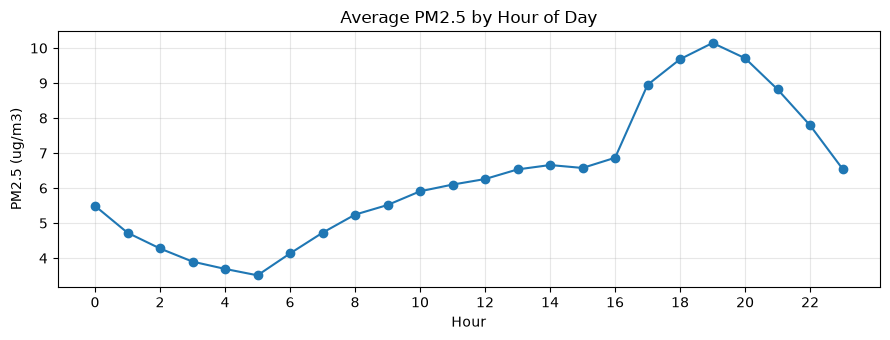

In [31]:
# --- Check what we collected ---

import matplotlib.pyplot as plt

print("Average PM2.5:", round(aq["pm2_5"].mean(), 1), "ug/m3")
print("Highest PM2.5:", round(aq["pm2_5"].max(), 1), "ug/m3")

print("\nMissing values in each column:")
print(aq.isna().sum())

# Average PM2.5 for each hour of the day
by_hour = aq.groupby(aq["time"].dt.hour)["pm2_5"].mean()

plt.figure(figsize=(9, 3.5))
plt.plot(by_hour.index, by_hour.values, marker="o")
plt.title("Average PM2.5 by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("PM2.5 (ug/m3)")
plt.xticks(range(0, 24, 2))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Exercise 3

1. Collect the air quality data for **Delhi (28.6139, 77.2090)** and compare the average
   PM2.5 with Bengaluru's. Which city is more polluted?
2. Increase `past_days` from 7 to 30. How many rows do you get now?
3. Add `"sulphur_dioxide"` and `"carbon_monoxide"` to the list of pollutants.

In [35]:
# 1.
# Delhi average PM2.5 = 77.2 ug/m3
# Bengaluru average PM2.5 = 6.3 ug/m3
# Therefore, Delhi is more polluted based on average PM2.5.

# 2.
# With past_days = 30, the API returned 840 rows.

# 3.
# Added sulphur_dioxide and carbon_monoxide successfully.
# The resulting DataFrame has 7 columns and 288 rows.

In [32]:
# 1. Collect air quality data for Delhi and compare average PM2.5

DELHI_LAT = 28.6139
DELHI_LON = 77.2090

delhi_params = {
    "latitude": DELHI_LAT,
    "longitude": DELHI_LON,
    "hourly": "pm2_5",
    "timezone": "Asia/Kolkata",
    "past_days": 7
}

try:
    delhi_response = requests.get(
        AQ_URL,
        params=delhi_params,
        timeout=20
    )

    print("Delhi status code:", delhi_response.status_code)

    delhi_data = delhi_response.json()
    delhi_df = pd.DataFrame(delhi_data["hourly"])
    delhi_df["time"] = pd.to_datetime(delhi_df["time"])

    delhi_avg = delhi_df["pm2_5"].mean()

    print("Delhi average PM2.5:", round(delhi_avg, 1), "ug/m3")
    print("Bengaluru average PM2.5:", round(aq["pm2_5"].mean(), 1), "ug/m3")

    if delhi_avg > aq["pm2_5"].mean():
        print("Delhi is more polluted based on average PM2.5.")
    elif delhi_avg < aq["pm2_5"].mean():
        print("Bengaluru is more polluted based on average PM2.5.")
    else:
        print("Both cities have the same average PM2.5.")

except Exception as e:
    print("Error:", e)

Delhi status code: 200
Delhi average PM2.5: 77.2 ug/m3
Bengaluru average PM2.5: 6.3 ug/m3
Delhi is more polluted based on average PM2.5.


In [33]:
# 2. Collect 30 days of air quality data

params_30 = {
    "latitude": 12.9716,
    "longitude": 77.5946,
    "hourly": "pm2_5,pm10,nitrogen_dioxide,ozone",
    "timezone": "Asia/Kolkata",
    "past_days": 30
}

response_30 = requests.get(
    AQ_URL,
    params=params_30,
    timeout=20
)

print("Status code:", response_30.status_code)

data_30 = response_30.json()

aq_30 = pd.DataFrame(data_30["hourly"])
aq_30["time"] = pd.to_datetime(aq_30["time"])

print("Number of rows:", len(aq_30))
print("Shape:", aq_30.shape)

Status code: 200
Number of rows: 840
Shape: (840, 5)


In [34]:
# 3. Add sulphur dioxide and carbon monoxide

params_extra = {
    "latitude": 12.9716,
    "longitude": 77.5946,
    "hourly": "pm2_5,pm10,nitrogen_dioxide,ozone,sulphur_dioxide,carbon_monoxide",
    "timezone": "Asia/Kolkata",
    "past_days": 7
}

response_extra = requests.get(
    AQ_URL,
    params=params_extra,
    timeout=20
)

print("Status code:", response_extra.status_code)

data_extra = response_extra.json()

aq_extra = pd.DataFrame(data_extra["hourly"])
aq_extra["time"] = pd.to_datetime(aq_extra["time"])

print("Columns collected:")
print(list(aq_extra.columns))

print("\nShape:", aq_extra.shape)

print("\nFirst 5 records:")
print(aq_extra.head())

Status code: 200
Columns collected:
['time', 'pm2_5', 'pm10', 'nitrogen_dioxide', 'ozone', 'sulphur_dioxide', 'carbon_monoxide']

Shape: (288, 7)

First 5 records:
                 time  pm2_5  pm10  nitrogen_dioxide  ozone  sulphur_dioxide  \
0 2026-08-24 00:00:00    5.8   7.7               9.3   31.0              4.0   
1 2026-08-24 01:00:00    4.9   6.5               7.6   32.0              3.7   
2 2026-08-24 02:00:00    4.2   5.6               6.3   32.0              3.5   
3 2026-08-24 03:00:00    3.7   5.1               5.4   32.0              3.3   
4 2026-08-24 04:00:00    3.3   4.5               4.9   32.0              3.3   

   carbon_monoxide  
0            166.0  
1            141.0  
2            124.0  
3            113.0  
4            109.0  


### Result — Experiment 3

**API used:Open-Meteo Air Quality API**

**Pollutants collected:PM2.5, PM10, Nitrogen Dioxide (NO₂), Ozone (O₃)**

**Number of records:288**

**Observation:Air quality data was successfully collected from the Open-Meteo Air Quality API for Bengaluru. The average PM2.5 concentration was 6.3 µg/m³. Delhi had a higher average PM2.5 concentration of 77.2 µg/m³ compared to Bengaluru, indicating that Delhi was more polluted based on PM2.5. Additional pollutants such as sulphur dioxide and carbon monoxide were also successfully collected.**

> ...

# Creating a Large Air Quality & Weather Dataset

## Objective

Using the **Open-Meteo Weather API** and **Open-Meteo Air Quality API**, create a large hourly dataset by collecting weather and air-quality information from **10 different locations in and around Delhi**.

### 📌 Dataset Requirements

- **Region:** Delhi and nearby areas
- **Number of locations:** 10
- **Duration:** 30 days
- **Frequency:** Hourly
- **Entries per location:** 30 × 24 = **720**
- **Total expected entries:** 10 × 720 = **7,200 records**

### 📍 Suggested Locations

1. Connaught Place
2. Rohini
3. Dwarka
4. Saket
5. Lajpat Nagar
6. Karol Bagh
7. Anand Vihar
8. Vasant Kunj
9. Noida
10. Delhi Airport

### 🌦️ Weather Variables

Collect the following weather information:

- Temperature
- Relative humidity
- Precipitation
- Wind speed

### 🌫️ Air Quality Variables

Collect the following air-pollution information:

- PM2.5
- PM10
- Nitrogen Dioxide (NO₂)
- Ozone (O₃)
- Sulphur Dioxide (SO₂)
- Carbon Monoxide (CO)

### 📊 Expected Dataset Structure

The final dataset should contain columns such as:

`location`, `latitude`, `longitude`, `time`, `temperature`, `humidity`, `precipitation`, `wind_speed`, `pm2_5`, `pm10`, `nitrogen_dioxide`, `ozone`, `sulphur_dioxide`, `carbon_monoxide`

### 🧹 Data Processing Tasks

1. Collect data from the APIs for all 10 locations.
2. Convert the API responses into Pandas DataFrames.
3. Add the location name, latitude, and longitude.
4. Combine all locations into one dataset.
5. Check for missing or invalid values.
6. Handle missing values appropriately.
7. Save the final dataset as a CSV file.

### 🔍 Analysis Question

After creating the dataset, answer the following:

> **Which location in and around Delhi has the highest average PM2.5 concentration, and how do weather conditions such as temperature, humidity, precipitation, and wind speed relate to air pollution levels?**

### 📈 Dataset Size

**10 Locations × 30 Days × 24 Hours = 7,200 hourly records**

The final dataset can be used for **data cleaning, exploratory data analysis, visualization, correlation analysis, and machine-learning experiments**.

In [16]:
# --- Final check: list all the files we collected ---

print("Files collected in this lab:\n")
for f in sorted(DATA.glob("*")):
    print(f"  {f.name:22s}  {f.stat().st_size:>8,} bytes")

Files collected in this lab:

  air_quality.csv           11,187 bytes
  House.html              1,774,801 bytes
  Magicbrick.html         1,502,328 bytes
  Magicbrick_files          81,920 bytes
  weather.csv                5,600 bytes


---
## Viva Questions

1. What is web scraping?
2. What is the difference between web scraping and using an API?
3. What is `robots.txt` and why should you check it?
4. What does BeautifulSoup do?
5. What is the difference between `find()` and `find_all()`?
6. What is JSON? How is it related to a Python dictionary?
7. What does status code 200 mean? What does 404 mean?
8. What is a query parameter in an API call?
9. Why should you wait a few seconds between requests?
10. Why is using an API better than scraping the same website?
11. What does `pd.read_html()` do?
12. Why do we save the collected data as a CSV file?

## Conclusion

> Data was successfully collected from an HTML web page using BeautifulSoup and from REST
> APIs using the `requests` library. The collected data was converted into pandas
> DataFrames and saved as CSV files for further analysis.

